# 🌏 CVI-HazardFusion: Dynamic Real-Time Multi-Hazard Risk Intelligence
## Bangladesh | Sentinel-1 × MODIS × SRTM × CHIRPS × WorldPop
---
| Item | Detail |
|------|--------|
| **Challenge** | RIMES Regional Innovation Challenge 2026 — Theme 01 |
| **System** | CVI-HazardFusion v1.0 |
| **Window** | Last 30 days (auto-updated) |
| **Hazards** | Flood + Drought + Landslide |
| **Districts** | All 64, Bangladesh |

### 🔧 Fixes in this version
- ✅ **Formula box** → moved to TOP-RIGHT, outside map boundary
- ✅ **Title** → raised above map, no overlap with any element
- ✅ **Data Sources** → bottom panel, full width
- ✅ **Lat/Lon gridlines** → all 4 sides
- ✅ **Scale bar** → 100 km, bottom-right
- ✅ **Analytics charts** → 3-panel professional figure
- ✅ **Bubble chart** → CVI vs Hazard risk space


In [1]:
# ═══════════════════════════════════════════
# CELL 1 — Install Dependencies
# ═══════════════════════════════════════════
import subprocess, sys
pkgs = [
    'earthengine-api>=0.1.384',
    'geemap>=0.30.0',
    'geopandas>=0.14.0',
    'matplotlib>=3.8.0',
    'numpy>=1.24.0',
    'pandas>=2.1.0',
    'scikit-learn>=1.3.0',
    'requests>=2.31.0',
    'folium>=0.15.0',
    'branca>=0.7.0',
    'scipy>=1.11.0',
]
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install','-q',p], capture_output=True)
print('✅ All libraries installed')


✅ All libraries installed


In [2]:
# ═══════════════════════════════════════════
# CELL 2 — Google Earth Engine Authentication
# ─── ONLY MANUAL STEP IN ENTIRE NOTEBOOK ───
# ═══════════════════════════════════════════
import ee
ee.Authenticate()           # Opens browser once — paste the code back
GEE_PROJECT = 'work-480002'   # ← CHANGE THIS to your project
ee.Initialize(project=GEE_PROJECT)
print('✅ GEE connected:', GEE_PROJECT)


✅ GEE connected: work-480002


In [3]:
# ═══════════════════════════════════════════
# CELL 3 — All Imports + Config + Color Theme
# ═══════════════════════════════════════════
import ee, geopandas as gpd, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.lines  import Line2D
from sklearn.preprocessing import MinMaxScaler
import requests, zipfile, io, os, warnings
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

# ── Date window (always last 30 days)
TODAY        = datetime.utcnow()
DATE_END     = TODAY.strftime('%Y-%m-%d')
DATE_START   = (TODAY - timedelta(days=30)).strftime('%Y-%m-%d')
DATE_BEFORE  = (TODAY - timedelta(days=60)).strftime('%Y-%m-%d')
MONTH        = TODAY.month

# ── Color palette (dark academic)
BG   = '#0D1117'   # Background
PBG  = '#161B22'   # Panel background
ACC  = '#00E5C8'   # Accent teal
ACC2 = '#58A6FF'   # Accent blue
RCOL = {
    'Critical': '#FF4444',
    'High':     '#FF8C00',
    'Moderate': '#FFD700',
    'Low':      '#22C55E',
}

def classify(d):
    if d >= 75: return 'Critical'
    elif d >= 50: return 'High'
    elif d >= 25: return 'Moderate'
    return 'Low'

# ── GEE collections
BD_GEOM   = (ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
               .filter(ee.Filter.eq('country_na','Bangladesh'))).geometry()
BGD_ADMIN = (ee.FeatureCollection('FAO/GAUL/2015/level2')
               .filter(ee.Filter.eq('ADM0_NAME','Bangladesh')))

print(f'✅ Config ready | Period: {DATE_START} → {DATE_END}')
print(f'   Background: {BG}  |  Accent: {ACC}')


✅ Config ready | Period: 2026-02-23 → 2026-03-25
   Background: #0D1117  |  Accent: #00E5C8


In [4]:
# ═══════════════════════════════════════════
# CELL 4 — Download Bangladesh Boundaries
# Auto-fetch from GADM — no manual upload
# ═══════════════════════════════════════════
GADM_URL = 'https://geodata.ucdavis.edu/gadm/gadm4.0/shp/gadm40_BGD_shp.zip'
if not os.path.exists('gadm_bd/gadm40_BGD_2.shp'):
    print('📥 Downloading Bangladesh boundaries from GADM ...')
    r = requests.get(GADM_URL, timeout=180)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        os.makedirs('gadm_bd', exist_ok=True)
        z.extractall('gadm_bd')
    print('✅ Download complete')
else:
    print('✅ Boundaries already downloaded')

districts = (gpd.read_file('gadm_bd/gadm40_BGD_2.shp')
               .to_crs('EPSG:4326')
               .rename(columns={'NAME_2':'district','NAME_1':'division'}))
print(f'✅ {len(districts)} districts | CRS: EPSG:4326')
print(f'   Bounds: {districts.total_bounds.round(2)}')


📥 Downloading Bangladesh boundaries from GADM ...
✅ Download complete
✅ 64 districts | CRS: EPSG:4326
   Bounds: [88.01 20.74 92.67 26.63]


In [5]:
# ═══════════════════════════════════════════
# CELL 5 — Hazard 1: Flood (Sentinel-1 SAR)
# Method: VH backscatter change detection
# Ref: Wagner et al. (2026) Remote Sens. Env.
# ═══════════════════════════════════════════
def s1_mean(start, end):
    return (ee.ImageCollection('COPERNICUS/S1_GRD')
              .filterBounds(BD_GEOM).filterDate(start, end)
              .filter(ee.Filter.eq('instrumentMode','IW'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation','VH'))
              .select('VH').mean())

s1_now    = s1_mean(DATE_START,  DATE_END)
s1_before = s1_mean(DATE_BEFORE, DATE_START)

# Flood pixels: backscatter dropped >3.5 dB
# Mask permanent water (JRC seasonality ≥10 months)
perm_water = (ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
                .select('seasonality').gte(10))
flood_raw = (s1_before.subtract(s1_now).gt(3.5)
               .where(perm_water, 0)
               .rename('flood'))

print('✅ Flood layer computed (Sentinel-1 IW VH, 10 m)')
print(f'   Baseline: {DATE_BEFORE} → {DATE_START}')
print(f'   Current:  {DATE_START} → {DATE_END}')


✅ Flood layer computed (Sentinel-1 IW VH, 10 m)
   Baseline: 2026-01-24 → 2026-02-23
   Current:  2026-02-23 → 2026-03-25


In [6]:
# ═══════════════════════════════════════════
# CELL 6 — Hazard 2: Drought (MODIS NDVI)
# Method: Current NDVI vs 5-year calendar baseline
# Ref: Gu et al. (2008) GRL doi:10.1029/2008GL035772
# ═══════════════════════════════════════════
ndvi_now = (ee.ImageCollection('MODIS/061/MOD13A2')
              .filterBounds(BD_GEOM)
              .filterDate(DATE_START, DATE_END)
              .select('NDVI').mean().multiply(0.0001))

# 5-year same-month baseline (2019-2023)
baseline_imgs = []
for yr in range(2019, 2024):
    m0 = f'{yr}-{MONTH:02d}-01'
    m1 = f'{yr}-{MONTH:02d}-28'
    img = (ee.ImageCollection('MODIS/061/MOD13A2')
             .filterBounds(BD_GEOM).filterDate(m0, m1)
             .select('NDVI').mean().multiply(0.0001))
    baseline_imgs.append(img)
ndvi_baseline = ee.ImageCollection(baseline_imgs).mean()

# Drought = NDVI deficit (inverted anomaly, clipped to positive values)
drought_raw = (ndvi_baseline.subtract(ndvi_now)
                 .max(ee.Image(0))
                 .rename('drought'))

print('✅ Drought layer computed (MODIS MOD13A2, 500 m)')
print(f'   Baseline years: 2019–2023, Month: {MONTH:02d}')


✅ Drought layer computed (MODIS MOD13A2, 500 m)
   Baseline years: 2019–2023, Month: 03


In [7]:
# ═══════════════════════════════════════════
# CELL 7 — Hazard 3: Landslide (SRTM × CHIRPS)
# Method: Slope susceptibility × rainfall trigger
# Ref: Sufi et al. (2022) Nat. Hazards 113(2)
# ═══════════════════════════════════════════
slope = ee.Terrain.slope(ee.Image('USGS/SRTMGL1_003'))  # degrees (0–90)

rainfall_30d = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                  .filterBounds(BD_GEOM)
                  .filterDate(DATE_START, DATE_END)
                  .select('precipitation').sum())  # mm

# Normalize separately (slope: 0-45°, rainfall: 0-500 mm)
slope_n    = slope.unitScale(0, 45)
rainfall_n = rainfall_30d.unitScale(0, 500)

# Product = compound susceptibility
landslide_raw = slope_n.multiply(rainfall_n).rename('landslide')

print('✅ Landslide layer computed (SRTM 30m × CHIRPS 5km)')
print('   Slope range: 0–45° | Rainfall range: 0–500 mm/month')


✅ Landslide layer computed (SRTM 30m × CHIRPS 5km)
   Slope range: 0–45° | Rainfall range: 0–500 mm/month


In [8]:
# ═══════════════════════════════════════════
# CELL 8 — Proxy Climate Vulnerability Index
# CVI = 0.35×Population + 0.35×Poverty + 0.30×Historical Flood
# Ref: UNDP LoGIC CVI Framework (Bangladesh, 2025)
# ═══════════════════════════════════════════

# WorldPop 2020 (population density, 100m)
pop_img = (ee.ImageCollection('WorldPop/GP/100m/pop')
             .filter(ee.Filter.eq('country','BGD'))
             .filter(ee.Filter.eq('year',2020))
             .first())

# VIIRS Nightlight 2023 (inverted = poverty proxy, 500m)
viirs_img = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
               .filterDate('2023-01-01','2023-12-31')
               .select('avg_rad').mean().multiply(-1))  # invert: darker = poorer

# JRC Global Surface Water — historical flood occurrence (30m)
jrc_img = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence')

# ── Zonal statistics helper ──────────────────────────
def zonal_mean(img, col_name, scale=500):
    z = img.reduceRegions(
        collection=BGD_ADMIN,
        reducer=ee.Reducer.mean(),
        scale=scale, crs='EPSG:4326')
    rows = []
    for f in z.select(['ADM2_NAME','mean']).getInfo()['features']:
        rows.append({
            'district': f['properties']['ADM2_NAME'],
            col_name:   f['properties'].get('mean') or 0
        })
    return pd.DataFrame(rows)

print('⏳ Computing zonal statistics (may take 4-6 minutes) ...')
flood_df     = zonal_mean(flood_raw,     'flood_score',  scale=10)
drought_df   = zonal_mean(drought_raw,   'drought_raw',  scale=500)
landslide_df = zonal_mean(landslide_raw, 'landslide_raw',scale=90)
pop_df       = zonal_mean(pop_img,       'pop_density',  scale=100)
pov_df       = zonal_mean(viirs_img,     'poverty_raw',  scale=500)
jrc_df       = zonal_mean(jrc_img,       'hist_flood',   scale=30)

# Clip poverty to non-negative
pov_df['poverty_raw'] = pov_df['poverty_raw'].clip(lower=0)

print('✅ All zonal statistics complete')
print(f'   Districts: {len(flood_df)} flood | {len(drought_df)} drought | {len(landslide_df)} landslide')


⏳ Computing zonal statistics (may take 4-6 minutes) ...
✅ All zonal statistics complete
   Districts: 64 flood | 64 drought | 64 landslide


In [9]:
# ═══════════════════════════════════════════
# CELL 9 — Compute Dynamic Risk Score (DRS)
# DRS = CVI × [0.50×Flood + 0.25×Drought + 0.25×Landslide]
# ═══════════════════════════════════════════
sc = MinMaxScaler()

# ── Build proxy CVI ──────────────────────────────────────
vuln = (pop_df
          .merge(pov_df, on='district')
          .merge(jrc_df, on='district'))

vuln['pop_n']   = sc.fit_transform(vuln[['pop_density']]).flatten()
vuln['pov_n']   = sc.fit_transform(vuln[['poverty_raw']]).flatten()
vuln['jrc_n']   = sc.fit_transform(vuln[['hist_flood']]).flatten()
vuln['proxy_cvi'] = 0.35*vuln['pop_n'] + 0.35*vuln['pov_n'] + 0.30*vuln['jrc_n']

# ── Merge all hazards ─────────────────────────────────────
df = (vuln[['district','proxy_cvi']]
        .merge(flood_df,     on='district', how='left')
        .merge(drought_df,   on='district', how='left')
        .merge(landslide_df, on='district', how='left')
        .fillna(0))

# ── Normalize hazards ─────────────────────────────────────
df['flood_n']     = sc.fit_transform(df[['flood_score']]).flatten()
df['drought_n']   = sc.fit_transform(df[['drought_raw']]).flatten()
df['landslide_n'] = sc.fit_transform(df[['landslide_raw']]).flatten()
df['cvi_n']       = sc.fit_transform(df[['proxy_cvi']]).flatten()

# ── Compound Hazard & DRS ─────────────────────────────────
df['compound'] = (0.50 * df['flood_n'] +
                  0.25 * df['drought_n'] +
                  0.25 * df['landslide_n'])

raw_drs        = df['cvi_n'] * df['compound']
df['DRS']      = sc.fit_transform(raw_drs.values.reshape(-1,1)).flatten() * 100
df['risk_level'] = df['DRS'].apply(classify)
df = df.sort_values('DRS', ascending=False).reset_index(drop=True)

# ── Merge with GeoDataFrame ───────────────────────────────
map_gdf = (districts
             .merge(df[['district','DRS','risk_level',
                         'flood_n','drought_n','landslide_n','cvi_n']],
                    on='district', how='left')
             .fillna(0))

# ── Save CSV ─────────────────────────────────────────────
df.to_csv('outputs/drs_results.csv', index=False)

print('═'*52)
print('  DRS RESULTS SUMMARY')
print('═'*52)
for cat in ['Critical','High','Moderate','Low']:
    sub = df[df.risk_level==cat]
    print(f'  {cat:<12}: {len(sub):>2} districts  '
          f'(DRS range: {sub.DRS.min():.1f}–{sub.DRS.max():.1f})')
print('═'*52)
print(f'  Top 5 districts:')
for _,r in df.head(5).iterrows():
    print(f'    {r.district:<16} DRS={r.DRS:.1f}  [{r.risk_level}]')


════════════════════════════════════════════════════
  DRS RESULTS SUMMARY
════════════════════════════════════════════════════
  Critical    :  2 districts  (DRS range: 84.4–100.0)
  High        :  3 districts  (DRS range: 57.6–68.3)
  Moderate    : 12 districts  (DRS range: 25.7–39.9)
  Low         : 47 districts  (DRS range: 0.0–24.6)
════════════════════════════════════════════════════
  Top 5 districts:
    Dhaka            DRS=100.0  [Critical]
    Rangamati        DRS=84.4  [Critical]
    Sirajganj        DRS=68.3  [High]
    Manikganj        DRS=59.1  [High]
    Bogra            DRS=57.6  [High]


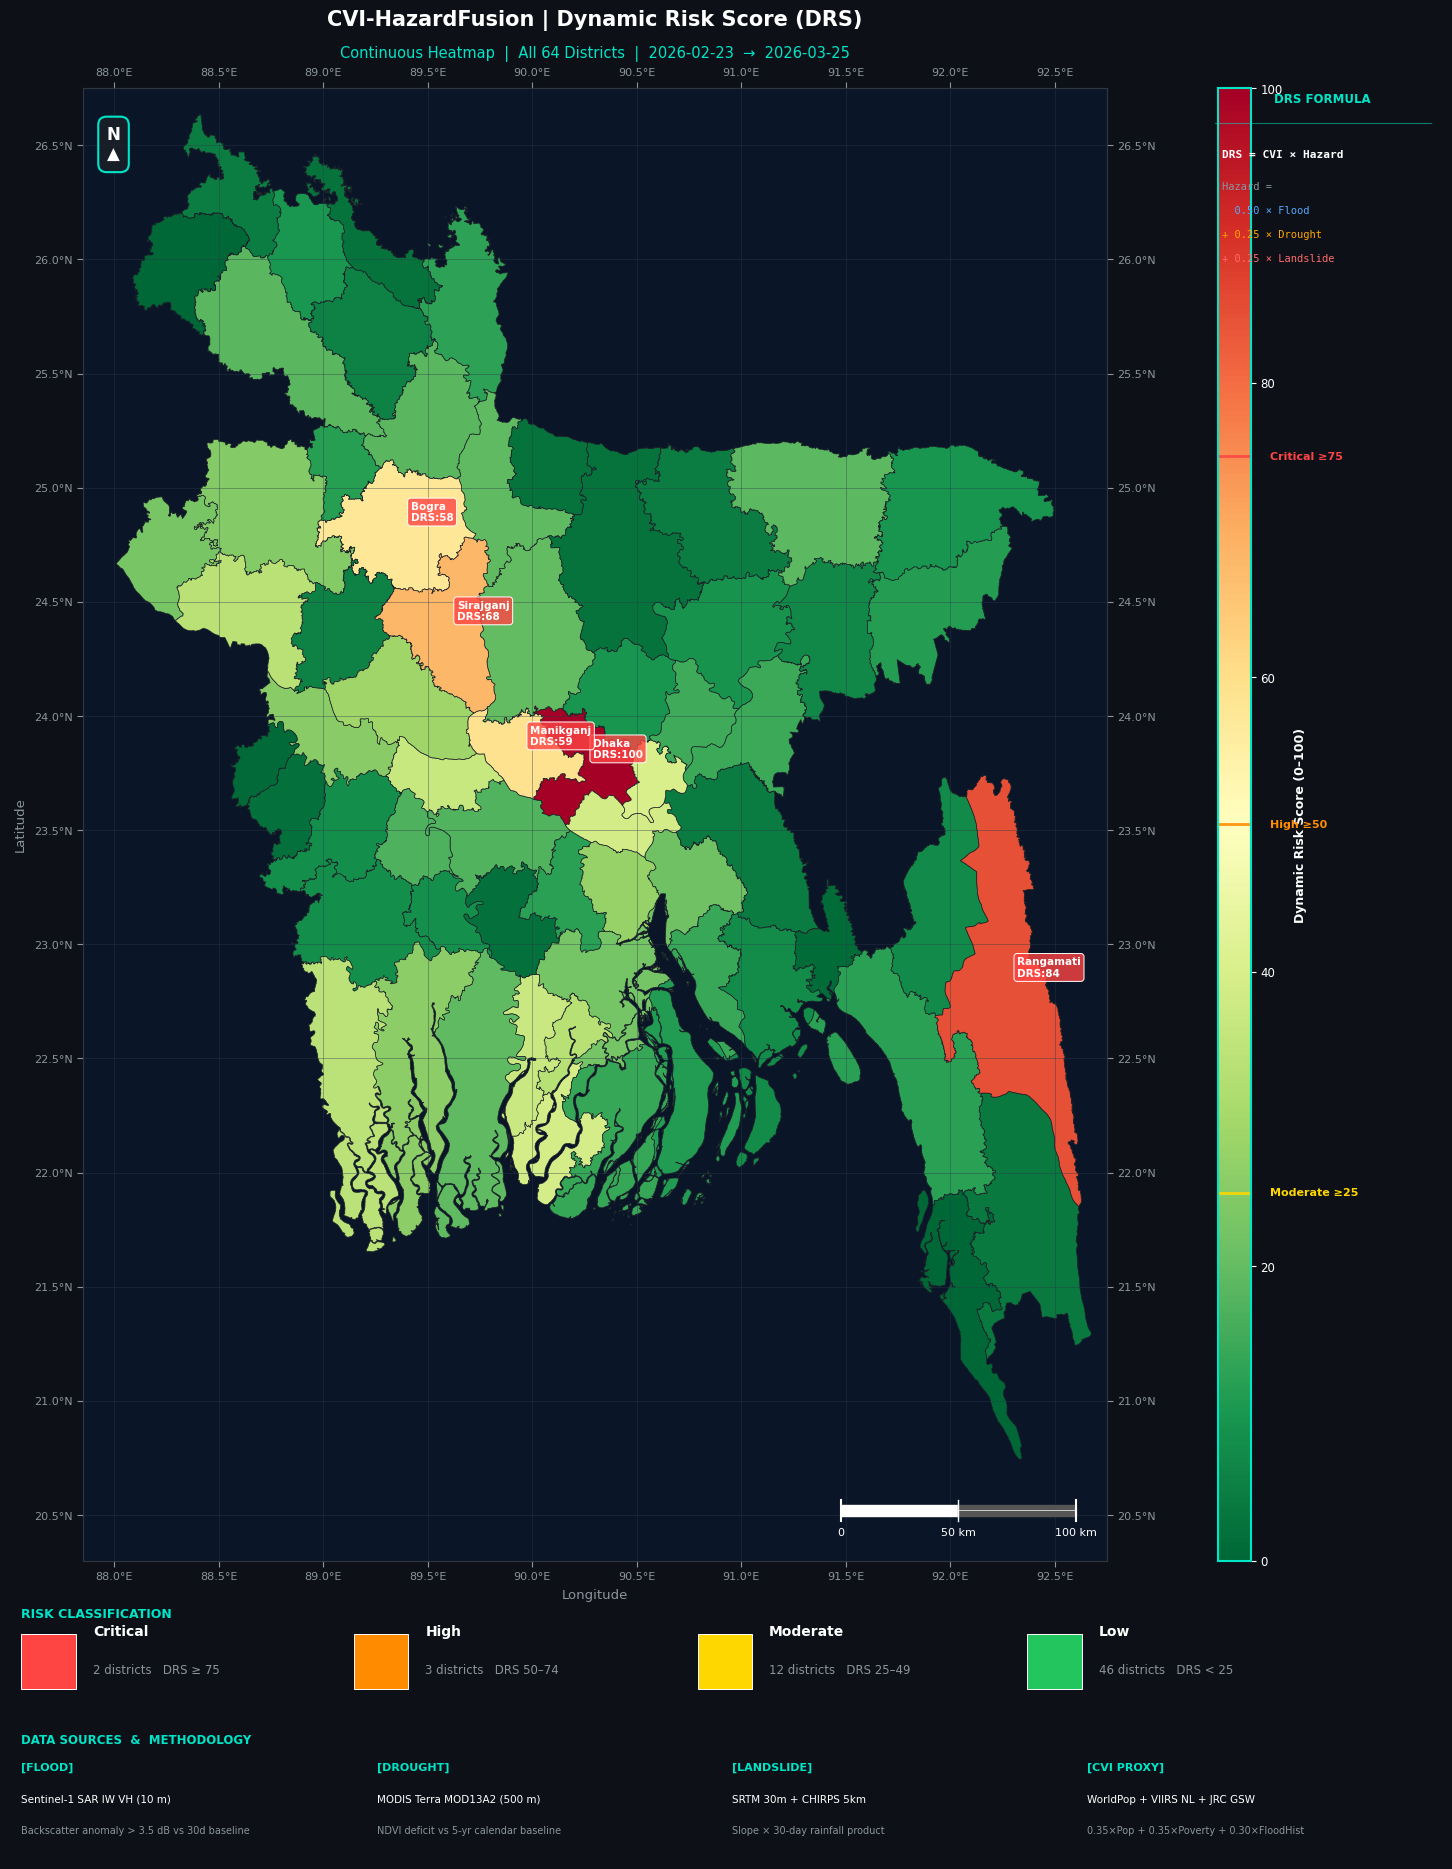

✅ Map 1 saved → outputs/map_1_DRS_FINAL.png


In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — MAP 1: Continuous DRS Heatmap (FULLY FIXED)
#
# LAYOUT (no overlaps):
#   ┌─────────────────────────────────────────────────────────┐
#   │  TITLE (fig.text, above everything, y=0.975)            │
#   │  Subtitle (fig.text, y=0.955)                           │
#   ├──────────────────────────────────┬──────────────────────┤
#   │                                  │  Formula box (top-   │
#   │   MAP BODY (axes 0.05-0.82)      │  right, OUTSIDE map) │
#   │   + lat/lon grid                 │  Colorbar (0.85-0.88)│
#   │   + compass (top-left inside)    │                      │
#   │   + scale bar (bottom-right)     │                      │
#   ├──────────────────────────────────┴──────────────────────┤
#   │  Risk Legend panel  (y=0.09–0.15)                       │
#   ├─────────────────────────────────────────────────────────┤
#   │  Data Sources panel (y=0.00–0.075)                      │
#   └─────────────────────────────────────────────────────────┘
# ═══════════════════════════════════════════════════════════════════

LON_TICKS = [88.0,88.5,89.0,89.5,90.0,90.5,91.0,91.5,92.0,92.5]
LAT_TICKS = [20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0,24.5,25.0,25.5,26.0,26.5]
XMIN,XMAX = 87.85, 92.75
YMIN,YMAX = 20.30, 26.75
KM_PER_DEG = 89.0    # at ~23°N
SCALE_KM   = 100
SCALE_DEG  = SCALE_KM / KM_PER_DEG

fig = plt.figure(figsize=(15, 19), facecolor=BG)

# ── TITLES (placed first, above all axes) ──────────────────────────
fig.text(0.43, 0.973,
    'CVI-HazardFusion | Dynamic Risk Score (DRS)',
    ha='center', color='white', fontsize=15, fontweight='bold')
fig.text(0.43, 0.956,
    f'Continuous Heatmap  |  All 64 Districts  |  {DATE_START}  →  {DATE_END}',
    ha='center', color=ACC, fontsize=10.5)

# ── MAP AXIS (leaves room top for title, right for formula+colorbar,
#              bottom for legend + data sources) ──────────────────────
# [left, bottom, width, height]
ax = fig.add_axes([0.04, 0.165, 0.78, 0.775])
ax.set_facecolor('#0A1628')

# ── 1. Choropleth fill ─────────────────────────────────────────────
map_gdf.plot(column='DRS', cmap='RdYlGn_r',
             linewidth=0.5, edgecolor='#1C2128',
             ax=ax, legend=False, vmin=0, vmax=100,
             missing_kwds={'color':'#21262D'})

# ── 2. Lat/Lon gridlines ──────────────────────────────────────────
for lon in LON_TICKS:
    ax.axvline(lon, color='#2A3A4A', lw=0.5, alpha=0.55, zorder=1)
for lat in LAT_TICKS:
    ax.axhline(lat, color='#2A3A4A', lw=0.5, alpha=0.55, zorder=1)

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)

# Bottom x-axis (longitude)
ax.set_xticks(LON_TICKS)
ax.set_xticklabels([f'{v:.1f}°E' for v in LON_TICKS], color='#8B949E', fontsize=8)
ax.xaxis.set_tick_params(length=4, color='#8B949E')

# Left y-axis (latitude)
ax.set_yticks(LAT_TICKS)
ax.set_yticklabels([f'{v:.1f}°N' for v in LAT_TICKS], color='#8B949E', fontsize=8)
ax.yaxis.set_tick_params(length=4, color='#8B949E')

# Axis labels
ax.set_xlabel('Longitude', color='#8B949E', fontsize=9.5, labelpad=5)
ax.set_ylabel('Latitude',  color='#8B949E', fontsize=9.5, labelpad=5)
for sp in ax.spines.values(): sp.set_edgecolor('#30363D')

# Top x-axis ticks
axt = ax.secondary_xaxis('top')
axt.set_xticks(LON_TICKS)
axt.set_xticklabels([f'{v:.1f}°E' for v in LON_TICKS], color='#8B949E', fontsize=8)
axt.tick_params(length=4, color='#8B949E')
for sp in axt.spines.values(): sp.set_edgecolor('#30363D')

# Right y-axis ticks
axr = ax.secondary_yaxis('right')
axr.set_yticks(LAT_TICKS)
axr.set_yticklabels([f'{v:.1f}°N' for v in LAT_TICKS], color='#8B949E', fontsize=8)
axr.tick_params(length=4, color='#8B949E')
for sp in axr.spines.values(): sp.set_edgecolor('#30363D')

# ── 3. COLORBAR (far right, between map top and bottom panels) ────
cbar_ax = fig.add_axes([0.845, 0.165, 0.022, 0.775])
norm    = plt.Normalize(0, 100)
sm      = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Dynamic Risk Score (0–100)',
               color='white', fontsize=9, fontweight='bold', labelpad=8)
cbar.ax.tick_params(colors='white', labelsize=8.5)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.outline.set_edgecolor(ACC)
cbar.outline.set_linewidth(1.5)

# Threshold lines on colorbar
for val, col, lbl in [(75,'#FF4444','Critical ≥75'),
                       (50,'#FF8C00','High ≥50'),
                       (25,'#FFD700','Moderate ≥25')]:
    cbar.ax.axhline(val, color=col, lw=2.0, alpha=0.9)
    cbar.ax.text(1.6, val, lbl, color=col, fontsize=8,
                 fontweight='bold', va='center', ha='left')

# ── 4. FORMULA BOX (TOP-RIGHT, outside map, inside figure) ────────
# Placed as a separate axis above colorbar, right side
ax_formula = fig.add_axes([0.835, 0.84, 0.16, 0.105])
ax_formula.set_facecolor('#1C2128')
ax_formula.set_xlim(0,1); ax_formula.set_ylim(0,1)
ax_formula.axis('off')
for sp in ax_formula.spines.values(): sp.set_edgecolor(ACC)
ax_formula.set_frame_on(True)

ax_formula.text(0.5, 0.93, 'DRS FORMULA',
    color=ACC, fontsize=8.5, fontweight='bold',
    ha='center', va='top')
ax_formula.axhline(0.78, color=ACC, lw=0.8, alpha=0.5,
    xmin=0.05, xmax=0.95)
formula_lines = [
    ('DRS = CVI × Hazard',    0.62, 'white', 8.0, 'bold'),
    ('Hazard =',               0.46, '#8B949E', 7.5, 'normal'),
    ('  0.50 × Flood',         0.34, '#58A6FF', 7.5, 'normal'),
    ('+ 0.25 × Drought',       0.22, '#FFA500', 7.5, 'normal'),
    ('+ 0.25 × Landslide',     0.10, '#FF6B6B', 7.5, 'normal'),
]
for text, y, color, fs, fw in formula_lines:
    ax_formula.text(0.08, y, text, color=color,
        fontsize=fs, fontweight=fw, va='center',
        fontfamily='monospace')

# ── 5. Top-5 District Labels ──────────────────────────────────────
for _, row in map_gdf.nlargest(5, 'DRS').iterrows():
    c = row.geometry.centroid
    ax.annotate(
        f"{row['district']}\nDRS:{row['DRS']:.0f}",
        xy=(c.x, c.y), xytext=(6, 5),
        textcoords='offset points',
        fontsize=7.5, color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='#FF4444CC', ec='white', lw=0.7))

# ── 6. Compass Rose (top-LEFT inside map) ────────────────────────
ax.text(0.030, 0.975, 'N\n▲', transform=ax.transAxes,
    ha='center', va='top', color='white',
    fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5',
              fc='#1C2128CC', ec=ACC, lw=1.5))

# ── 7. Scale bar (bottom-right inside map) ────────────────────────
sx0 = XMAX - SCALE_DEG - 0.15
sy0 = YMIN + 0.22
sy1 = sy0 + 0.06
# White fill half, black fill other half
ax.fill_between([sx0, sx0+SCALE_DEG/2],[sy0-0.025,sy0-0.025],
                [sy0+0.025,sy0+0.025], color='white')
ax.fill_between([sx0+SCALE_DEG/2,sx0+SCALE_DEG],[sy0-0.025,sy0-0.025],
                [sy0+0.025,sy0+0.025], color='#555')
ax.plot([sx0,sx0+SCALE_DEG],[sy0,sy0],color='white',lw=0.5)
ax.plot([sx0,sx0],[sy0-0.045,sy0+0.045],color='white',lw=1.5)
ax.plot([sx0+SCALE_DEG/2,sx0+SCALE_DEG/2],[sy0-0.045,sy0+0.045],color='white',lw=1)
ax.plot([sx0+SCALE_DEG,sx0+SCALE_DEG],[sy0-0.045,sy0+0.045],color='white',lw=1.5)
ax.text(sx0, sy0-0.11, '0', ha='center', color='white', fontsize=8)
ax.text(sx0+SCALE_DEG/2, sy0-0.11, '50 km', ha='center', color='white', fontsize=8)
ax.text(sx0+SCALE_DEG, sy0-0.11, f'{SCALE_KM} km', ha='center', color='white', fontsize=8)

# ── 8. BOTTOM PANEL: Risk Classification Legend ──────────────────
ax_leg = fig.add_axes([0.04, 0.093, 0.955, 0.058])
ax_leg.set_facecolor('#161B22')
ax_leg.set_xlim(0,1); ax_leg.set_ylim(0,1); ax_leg.axis('off')
for sp in ax_leg.spines.values(): sp.set_edgecolor(ACC)
ax_leg.set_frame_on(True)

ax_leg.text(0.008, 0.82, 'RISK CLASSIFICATION',
    color=ACC, fontsize=9, fontweight='bold', va='top')

x_pos = [0.008, 0.24, 0.48, 0.71]
ranges = ['≥ 75','50–74','25–49','< 25']
for i, (risk, color) in enumerate(RCOL.items()):
    count = len(map_gdf[map_gdf['risk_level']==risk])
    xp = x_pos[i]
    ax_leg.add_patch(Rectangle((xp, 0.08), 0.038, 0.50,
        fc=color, ec='white', lw=0.7))
    ax_leg.text(xp+0.050, 0.60, risk,
        color='white', fontsize=10, fontweight='bold', va='center')
    ax_leg.text(xp+0.050, 0.25, f'{count} districts   DRS {ranges[i]}',
        color='#8B949E', fontsize=8.5, va='center')

# ── 9. BOTTOM PANEL: Data Sources ────────────────────────────────
ax_src = fig.add_axes([0.04, 0.008, 0.955, 0.075])
ax_src.set_facecolor('#0F1923')
ax_src.set_xlim(0,1); ax_src.set_ylim(0,1); ax_src.axis('off')
for sp in ax_src.spines.values(): sp.set_edgecolor('#30363D')
ax_src.set_frame_on(True)

ax_src.text(0.008, 0.88, 'DATA SOURCES  &  METHODOLOGY',
    color=ACC, fontsize=8.5, fontweight='bold', va='top')

srcs = [
    ('[FLOOD]',     'Sentinel-1 SAR IW VH (10 m)',    'Backscatter anomaly > 3.5 dB vs 30d baseline'),
    ('[DROUGHT]',   'MODIS Terra MOD13A2 (500 m)',     'NDVI deficit vs 5-yr calendar baseline'),
    ('[LANDSLIDE]', 'SRTM 30m + CHIRPS 5km',           'Slope × 30-day rainfall product'),
    ('[CVI PROXY]', 'WorldPop + VIIRS NL + JRC GSW',  '0.35×Pop + 0.35×Poverty + 0.30×FloodHist'),
]
for i, (lbl, ds, meth) in enumerate(srcs):
    xp = 0.008 + i*0.248
    ax_src.text(xp, 0.62, lbl,  color=ACC,       fontsize=8,   fontweight='bold')
    ax_src.text(xp, 0.40, ds,   color='white',    fontsize=7.5)
    ax_src.text(xp, 0.18, meth, color='#8B949E',  fontsize=7.0)

plt.savefig('outputs/map_1_DRS_FINAL.png',
    dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Map 1 saved → outputs/map_1_DRS_FINAL.png')


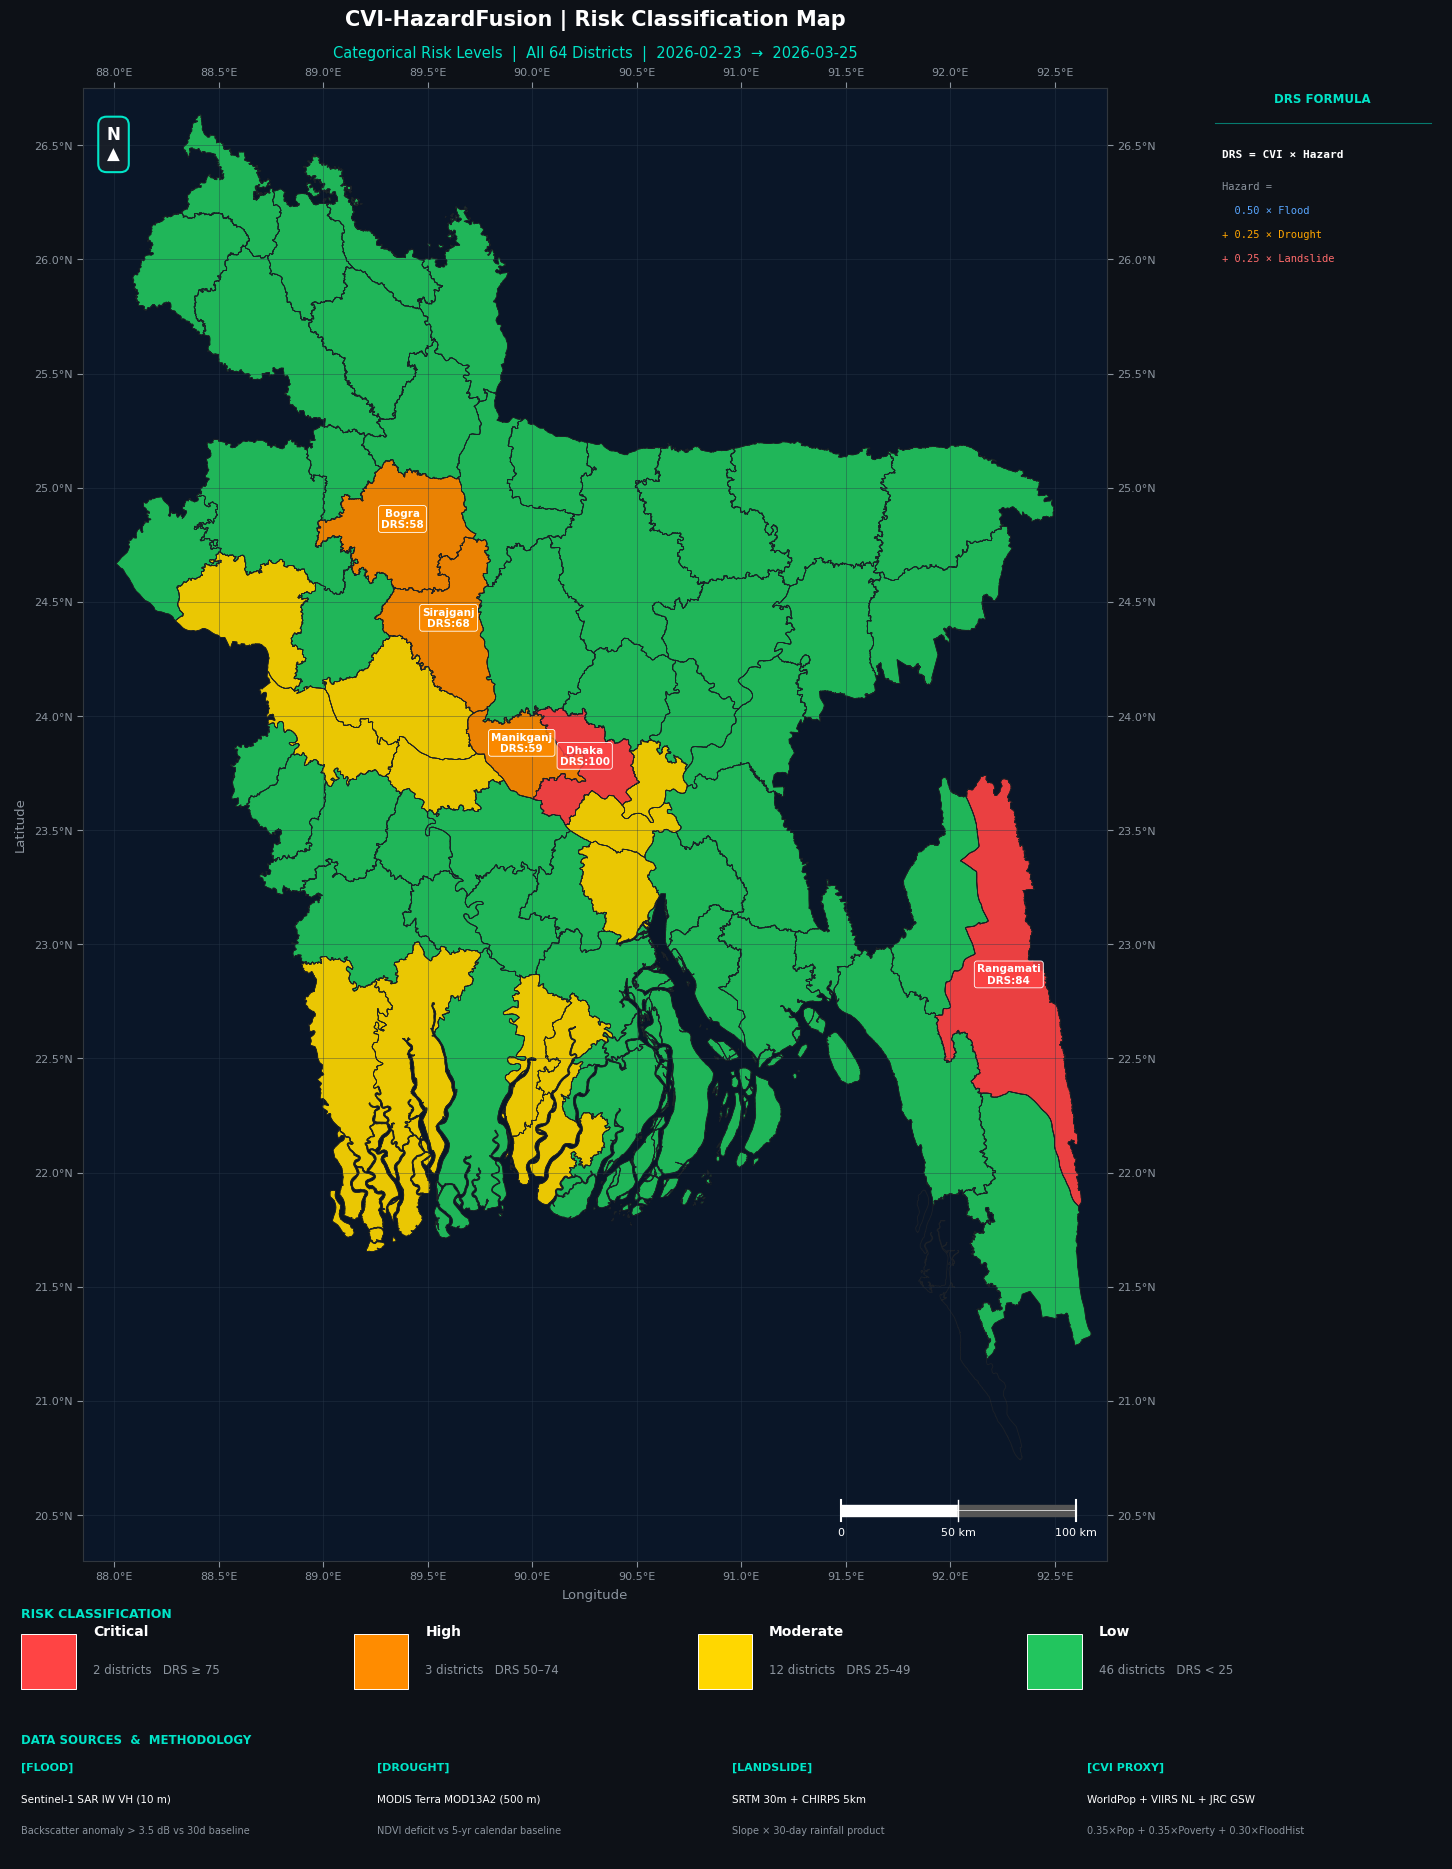

✅ Map 2 saved → outputs/map_2_classification_FINAL.png


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11 — MAP 2: Risk Classification (Categorical)
# Formula box: TOP-RIGHT outside map | Title: above map, no overlap
# ═══════════════════════════════════════════════════════════════════

fig2 = plt.figure(figsize=(15, 19), facecolor=BG)

# ── Titles ─────────────────────────────────────────────────────────
fig2.text(0.43, 0.973,
    'CVI-HazardFusion | Risk Classification Map',
    ha='center', color='white', fontsize=15, fontweight='bold')
fig2.text(0.43, 0.956,
    f'Categorical Risk Levels  |  All 64 Districts  |  {DATE_START}  →  {DATE_END}',
    ha='center', color=ACC, fontsize=10.5)

ax2 = fig2.add_axes([0.04, 0.165, 0.78, 0.775])
ax2.set_facecolor('#0A1628')

# ── Categorical fills ──────────────────────────────────────────────
for cat in ['Low','Moderate','High','Critical']:
    sub = map_gdf[map_gdf['risk_level']==cat]
    if len(sub):
        sub.plot(ax=ax2, color=RCOL[cat],
                 linewidth=0.5, edgecolor='#0D1117', alpha=0.92)
map_gdf.plot(ax=ax2, color='none', edgecolor='#1C2128', linewidth=0.6)

# ── Lat/Lon gridlines ──────────────────────────────────────────────
for lon in LON_TICKS:
    ax2.axvline(lon, color='#2A3A4A', lw=0.5, alpha=0.55, zorder=1)
for lat in LAT_TICKS:
    ax2.axhline(lat, color='#2A3A4A', lw=0.5, alpha=0.55, zorder=1)

ax2.set_xlim(XMIN, XMAX)
ax2.set_ylim(YMIN, YMAX)
ax2.set_xticks(LON_TICKS)
ax2.set_xticklabels([f'{v:.1f}°E' for v in LON_TICKS], color='#8B949E', fontsize=8)
ax2.xaxis.set_tick_params(length=4, color='#8B949E')
ax2.set_yticks(LAT_TICKS)
ax2.set_yticklabels([f'{v:.1f}°N' for v in LAT_TICKS], color='#8B949E', fontsize=8)
ax2.yaxis.set_tick_params(length=4, color='#8B949E')
ax2.set_xlabel('Longitude', color='#8B949E', fontsize=9.5, labelpad=5)
ax2.set_ylabel('Latitude',  color='#8B949E', fontsize=9.5, labelpad=5)
for sp in ax2.spines.values(): sp.set_edgecolor('#30363D')
ax2t = ax2.secondary_xaxis('top')
ax2t.set_xticks(LON_TICKS)
ax2t.set_xticklabels([f'{v:.1f}°E' for v in LON_TICKS], color='#8B949E', fontsize=8)
ax2t.tick_params(length=4, color='#8B949E')
for sp in ax2t.spines.values(): sp.set_edgecolor('#30363D')
ax2r = ax2.secondary_yaxis('right')
ax2r.set_yticks(LAT_TICKS)
ax2r.set_yticklabels([f'{v:.1f}°N' for v in LAT_TICKS], color='#8B949E', fontsize=8)
ax2r.tick_params(length=4, color='#8B949E')
for sp in ax2r.spines.values(): sp.set_edgecolor('#30363D')

# ── District labels: Critical + High ──────────────────────────────
for cat, fc_col in [('Critical','#FF4444CC'),('High','#FF8C00CC')]:
    for _, row in map_gdf[map_gdf['risk_level']==cat].iterrows():
        c = row.geometry.centroid
        ax2.annotate(
            f"{row['district']}\nDRS:{row['DRS']:.0f}",
            xy=(c.x, c.y), fontsize=7.5,
            color='white', fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.25',
                      fc=fc_col, ec='white', lw=0.6))

# ── FORMULA BOX: TOP-RIGHT, outside map axis ──────────────────────
ax2f = fig2.add_axes([0.835, 0.84, 0.16, 0.105])
ax2f.set_facecolor('#1C2128')
ax2f.set_xlim(0,1); ax2f.set_ylim(0,1); ax2f.axis('off')
for sp in ax2f.spines.values(): sp.set_edgecolor(ACC)
ax2f.set_frame_on(True)
ax2f.text(0.5, 0.93, 'DRS FORMULA',
    color=ACC, fontsize=8.5, fontweight='bold',
    ha='center', va='top')
ax2f.axhline(0.78, color=ACC, lw=0.8, alpha=0.5, xmin=0.05, xmax=0.95)
for text, y, color, fs, fw in [
    ('DRS = CVI × Hazard',    0.62, 'white',   8.0, 'bold'),
    ('Hazard =',               0.46, '#8B949E', 7.5, 'normal'),
    ('  0.50 × Flood',         0.34, '#58A6FF', 7.5, 'normal'),
    ('+ 0.25 × Drought',       0.22, '#FFA500', 7.5, 'normal'),
    ('+ 0.25 × Landslide',     0.10, '#FF6B6B', 7.5, 'normal'),
]:
    ax2f.text(0.08, y, text, color=color,
        fontsize=fs, fontweight=fw, va='center',
        fontfamily='monospace')

# ── Compass
ax2.text(0.030, 0.975, 'N\n▲', transform=ax2.transAxes,
    ha='center', va='top', color='white', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', fc='#1C2128CC', ec=ACC, lw=1.5))

# ── Scale bar
ax2.fill_between([sx0, sx0+SCALE_DEG/2],[sy0-0.025,sy0-0.025],
                 [sy0+0.025,sy0+0.025], color='white')
ax2.fill_between([sx0+SCALE_DEG/2,sx0+SCALE_DEG],[sy0-0.025,sy0-0.025],
                 [sy0+0.025,sy0+0.025], color='#555')
ax2.plot([sx0,sx0+SCALE_DEG],[sy0,sy0],color='white',lw=0.5)
ax2.plot([sx0,sx0],[sy0-0.045,sy0+0.045],color='white',lw=1.5)
ax2.plot([sx0+SCALE_DEG/2,sx0+SCALE_DEG/2],[sy0-0.045,sy0+0.045],color='white',lw=1)
ax2.plot([sx0+SCALE_DEG,sx0+SCALE_DEG],[sy0-0.045,sy0+0.045],color='white',lw=1.5)
ax2.text(sx0, sy0-0.11, '0', ha='center', color='white', fontsize=8)
ax2.text(sx0+SCALE_DEG/2, sy0-0.11, '50 km', ha='center', color='white', fontsize=8)
ax2.text(sx0+SCALE_DEG, sy0-0.11, f'{SCALE_KM} km', ha='center', color='white', fontsize=8)

# ── Bottom Legend
ax2_leg = fig2.add_axes([0.04, 0.093, 0.955, 0.058])
ax2_leg.set_facecolor('#161B22')
ax2_leg.set_xlim(0,1); ax2_leg.set_ylim(0,1); ax2_leg.axis('off')
for sp in ax2_leg.spines.values(): sp.set_edgecolor(ACC)
ax2_leg.set_frame_on(True)
ax2_leg.text(0.008, 0.82, 'RISK CLASSIFICATION',
    color=ACC, fontsize=9, fontweight='bold', va='top')
for i,(risk,color) in enumerate(RCOL.items()):
    count = len(map_gdf[map_gdf['risk_level']==risk])
    xp = x_pos[i]
    ax2_leg.add_patch(Rectangle((xp, 0.08), 0.038, 0.50,
        fc=color, ec='white', lw=0.7))
    ax2_leg.text(xp+0.050, 0.60, risk,
        color='white', fontsize=10, fontweight='bold', va='center')
    ax2_leg.text(xp+0.050, 0.25, f'{count} districts   DRS {ranges[i]}',
        color='#8B949E', fontsize=8.5, va='center')

# ── Bottom Data Sources
ax2_src = fig2.add_axes([0.04, 0.008, 0.955, 0.075])
ax2_src.set_facecolor('#0F1923')
ax2_src.set_xlim(0,1); ax2_src.set_ylim(0,1); ax2_src.axis('off')
for sp in ax2_src.spines.values(): sp.set_edgecolor('#30363D')
ax2_src.set_frame_on(True)
ax2_src.text(0.008, 0.88, 'DATA SOURCES  &  METHODOLOGY',
    color=ACC, fontsize=8.5, fontweight='bold', va='top')
for i, (lbl, ds, meth) in enumerate(srcs):
    xp = 0.008 + i*0.248
    ax2_src.text(xp, 0.62, lbl,  color=ACC,      fontsize=8, fontweight='bold')
    ax2_src.text(xp, 0.40, ds,   color='white',   fontsize=7.5)
    ax2_src.text(xp, 0.18, meth, color='#8B949E', fontsize=7.0)

plt.savefig('outputs/map_2_classification_FINAL.png',
    dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Map 2 saved → outputs/map_2_classification_FINAL.png')


# ═══════════════════════════════════════════════════════════════════
# CELL 12 — Figure 3: Analytics Charts (3-panel professional figure)
# Panel A: Top-20 DRS Horizontal Bar
# Panel B: Multi-hazard component stacked bar
# Panel C: Bubble chart — CVI vs Compound Hazard
# ═══════════════════════════════════════════════════════════════════

top20 = df.head(20).copy()
top15 = df.head(15).copy()

fig3, axes = plt.subplots(1, 3, figsize=(22, 9), facecolor=BG)
fig3.suptitle(
    f'CVI-HazardFusion | Multi-Hazard Analytics  |  {DATE_START} → {DATE_END}',
    color='white', fontsize=14, fontweight='bold', y=1.01)

for ax_i in axes:
    ax_i.set_facecolor(PBG)
    for sp in ax_i.spines.values(): sp.set_edgecolor('#30363D')
    ax_i.tick_params(colors='#8B949E')

# ── PANEL A: Top-20 DRS Horizontal Bar ─────────────────────────
ax_a = axes[0]
colors_a = [RCOL[r] for r in top20['risk_level']]
bars = ax_a.barh(range(len(top20)), top20['DRS'], color=colors_a,
                  edgecolor='none', alpha=0.88, height=0.75)
ax_a.set_yticks(range(len(top20)))
ax_a.set_yticklabels(top20['district'], color='white', fontsize=8.5)
ax_a.invert_yaxis()
ax_a.set_xlabel('Dynamic Risk Score (0–100)', color='#8B949E', fontsize=9)
ax_a.set_title('A. Top 20 Districts by DRS',
    color=ACC, fontsize=11, fontweight='bold', pad=8)
ax_a.axvline(75, color='#FF4444', lw=1.2, ls='--', alpha=0.7)
ax_a.axvline(50, color='#FF8C00', lw=1.2, ls='--', alpha=0.7)
ax_a.axvline(25, color='#FFD700', lw=1.2, ls='--', alpha=0.7)
ax_a.text(76, -0.8, 'Critical', color='#FF4444', fontsize=7.5, fontweight='bold')
ax_a.text(51, -0.8, 'High',     color='#FF8C00', fontsize=7.5, fontweight='bold')
ax_a.text(26, -0.8, 'Moderate', color='#FFD700', fontsize=7.5, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, top20['DRS'])):
    ax_a.text(val+0.8, i, f'{val:.0f}',
        va='center', color='white', fontsize=7.5)
ax_a.set_xlim(0, 115)
ax_a.xaxis.label.set_color('#8B949E')
ax_a.tick_params(axis='x', colors='#8B949E')

# ── PANEL B: Multi-Hazard Component Stacked Bar (Top 15) ──────
ax_b = axes[1]
bar_w = 0.6
x = np.arange(len(top15))
b1 = ax_b.bar(x, top15['flood_n']*50,    color='#58A6FF', width=bar_w,
               label='Flood (×0.50)',  alpha=0.9, edgecolor='none')
b2 = ax_b.bar(x, top15['drought_n']*25,  color='#FFA500', width=bar_w,
               bottom=top15['flood_n']*50,
               label='Drought (×0.25)', alpha=0.9, edgecolor='none')
b3 = ax_b.bar(x, top15['landslide_n']*25,color='#FF6B6B', width=bar_w,
               bottom=top15['flood_n']*50 + top15['drought_n']*25,
               label='Landslide (×0.25)',alpha=0.9,edgecolor='none')

ax_b.set_xticks(x)
ax_b.set_xticklabels(top15['district'], rotation=45, ha='right',
    color='white', fontsize=8)
ax_b.set_ylabel('Weighted Hazard Component', color='#8B949E', fontsize=9)
ax_b.set_title('B. Multi-Hazard Component Breakdown (Top 15)',
    color=ACC, fontsize=11, fontweight='bold', pad=8)
ax_b.legend(loc='upper right', facecolor='#1C2128',
    edgecolor=ACC, labelcolor='white', fontsize=8.5)
ax_b.tick_params(axis='y', colors='#8B949E')
ax_b.yaxis.label.set_color('#8B949E')

# ── PANEL C: Bubble Chart — CVI vs Compound Hazard ────────────
ax_c = axes[2]
cmap_risk = {'Critical':'#FF4444','High':'#FF8C00',
             'Moderate':'#FFD700','Low':'#22C55E'}

for cat in ['Low','Moderate','High','Critical']:
    sub = df[df['risk_level']==cat]
    ax_c.scatter(sub['compound']*100, sub['cvi_n']*100,
        s=sub['DRS']*3.5, c=cmap_risk[cat],
        alpha=0.78, edgecolors='white', linewidths=0.5,
        label=cat, zorder=3)

# Label top 5
for _, row in df.head(5).iterrows():
    ax_c.annotate(row['district'],
        xy=(row['compound']*100, row['cvi_n']*100),
        xytext=(5, 5), textcoords='offset points',
        fontsize=7.5, color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2',
                  fc='#FF4444AA', ec='none'))

ax_c.set_xlabel('Compound Hazard Score (0–100)', color='#D6B8B8', fontsize=9)
ax_c.set_ylabel('CVI Proxy Score (0–100)',        color='#FFFFFF', fontsize=9)
ax_c.set_title('C. Vulnerability × Hazard Risk Space\n(bubble size = DRS)',
    color=ACC, fontsize=11, fontweight='bold', pad=8)
ax_c.legend(loc='upper left', facecolor='#1C2128',
    edgecolor=ACC, labelcolor='white', fontsize=9,
    title='Risk Level', title_fontsize=9)
ax_c.tick_params(axis='both', colors='#D6B8B8')
ax_c.xaxis.label.set_color('#D6B8B8')
ax_c.yaxis.label.set_color('#D6B8B8')

# Quadrant shading
ax_c.axvline(50, color='#30363D', lw=0.8, ls='--', alpha=0.6)
ax_c.axhline(50, color='#30363D', lw=0.8, ls='--', alpha=0.6)
ax_c.text(75, 95, 'HIGH RISK ZONE', color='#FF4444',
    fontsize=8.5, fontweight='bold', ha='center', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analytics_charts_FINAL.png',
    dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Analytics charts saved → outputs/analytics_charts_FINAL.png')


In [13]:
# ═══════════════════════════════════════════
# CELL 13 — Interactive Folium Dashboard
# 5 layers: DRS, Flood, Drought, Landslide, CVI
# ═══════════════════════════════════════════
import folium
from folium import plugins
from branca.colormap import linear

m = folium.Map(
    location=[23.7, 90.4],
    zoom_start=7,
    tiles='CartoDB dark_matter',
    prefer_canvas=True)

def make_layer(gdf, col, cmap_colors, name, visible=True):
    cm = linear.YlOrRd_09.scale(gdf[col].min(), gdf[col].max())
    cm.caption = name
    fg = folium.FeatureGroup(name=name, show=visible)
    for _, row in gdf.iterrows():
        color = cm(row[col]) if not pd.isna(row[col]) else '#333'
        tooltip = (
            f"<b>{row['district']}</b> ({row.get('division','N/A')})<br>"
            f"DRS: <b style='color:#FF4444'>{row['DRS']:.1f}</b> "
            f"[{row.get('risk_level','N/A')}]<br>"
            f"Flood: {row.get('flood_n',0):.2f}  "
            f"Drought: {row.get('drought_n',0):.2f}  "
            f"Landslide: {row.get('landslide_n',0):.2f}<br>"
            f"CVI: {row.get('cvi_n',0):.2f}"
        )
        folium.GeoJson(
            row['geometry'].__geo_interface__,
            style_function=lambda x, c=color: {
                'fillColor': c, 'color':'#1C2128',
                'weight':0.6, 'fillOpacity':0.75},
            tooltip=folium.Tooltip(tooltip, sticky=True)
        ).add_to(fg)
    fg.add_to(m)
    m.add_child(cm)
    return fg

make_layer(map_gdf,'DRS',       'YlOrRd_09', '🔴 DRS (All Hazards)',   True)
make_layer(map_gdf,'flood_n',   'Blues_09',  '🌊 Flood Index',          False)
make_layer(map_gdf,'drought_n', 'YlOrBr_09', '☀️ Drought Index',        False)
make_layer(map_gdf,'landslide_n','Oranges_09','🏔️ Landslide Index',      False)
make_layer(map_gdf,'cvi_n',     'Purples_09','👥 CVI Proxy',             False)

folium.LayerControl(position='topright', collapsed=False).add_to(m)
plugins.Fullscreen().add_to(m)
plugins.MeasureControl(position='bottomleft').add_to(m)

m.save('outputs/interactive_dashboard.html')
print('✅ Interactive dashboard saved → outputs/interactive_dashboard.html')
print('   Open in browser to explore 5 layers with district tooltips')


✅ Interactive dashboard saved → outputs/interactive_dashboard.html
   Open in browser to explore 5 layers with district tooltips


In [14]:
# ═══════════════════════════════════════════
# CELL 14 — Final Summary
# ═══════════════════════════════════════════
import os
files = [
    ('outputs/drs_results.csv',                   'CSV', 'DRS scores for all 64 districts'),
    ('outputs/map_1_DRS_FINAL.png',               'PNG', 'Continuous DRS heatmap (FIXED)'),
    ('outputs/map_2_classification_FINAL.png',    'PNG', 'Categorical risk map (FIXED)'),
    ('outputs/analytics_charts_FINAL.png',        'PNG', '3-panel analytics figure'),
    ('outputs/interactive_dashboard.html',        'HTML','5-layer Folium dashboard'),
]

print('╔══════════════════════════════════════════════════════╗')
print('║    CVI-HazardFusion — ANALYSIS COMPLETE              ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Period: {DATE_START} → {DATE_END}  ║')
print('╠══════════════════════════════════════════════════════╣')
for fp, ftype, desc in files:
    kb = os.path.getsize(fp)/1024 if os.path.exists(fp) else 0
    print(f'║  [{ftype:<4}]  {desc:<36}  {kb:>5.0f}KB ║')
print('╠══════════════════════════════════════════════════════╣')
for cat in ['Critical','High','Moderate','Low']:
    sub = df[df.risk_level==cat]
    names = ', '.join(sub.head(3)['district'].tolist())
    print(f'║  {cat:<10}: {len(sub):>2} districts  ({names}...)')
print('╚══════════════════════════════════════════════════════╝')
print()
print('✅ UPLOAD TO GITHUB:')
print('   1. Create repo: cvi-hazardfusion')
print('   2. Upload this notebook to notebooks/')
print('   3. Upload outputs/ folder')
print('   4. Add README.md, requirements.txt, Makefile')


╔══════════════════════════════════════════════════════╗
║    CVI-HazardFusion — ANALYSIS COMPLETE              ║
╠══════════════════════════════════════════════════════╣
║  Period: 2026-02-23 → 2026-03-25  ║
╠══════════════════════════════════════════════════════╣
║  [CSV ]  DRS scores for all 64 districts          13KB ║
║  [PNG ]  Continuous DRS heatmap (FIXED)         1007KB ║
║  [PNG ]  Categorical risk map (FIXED)            989KB ║
║  [PNG ]  3-panel analytics figure                347KB ║
║  [HTML]  5-layer Folium dashboard              198903KB ║
╠══════════════════════════════════════════════════════╣
║  Critical  :  2 districts  (Dhaka, Rangamati...)
║  High      :  3 districts  (Sirajganj, Manikganj, Bogra...)
║  Moderate  : 12 districts  (Narayanganj, Barguna, Munshiganj...)
║  Low       : 47 districts  (Naogaon, Nawabganj, Barisal...)
╚══════════════════════════════════════════════════════╝

✅ UPLOAD TO GITHUB:
   1. Create repo: cvi-hazardfusion
   2. Upload this noteboo